In [12]:
import os

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, TensorDataset
torch.backends.cudnn.enabled = False

BATCH_SIZE = 32
LEARNING_RATE = 0.001
HIDDEN_SIZE = 256
NUM_LAYERS = 2
DROPOUT = 0.2
WINDOW_SIZE = 30
EARLY_STOP_PATIENCE = 20
MODEL_SAVE_PATH = "models/Vanilla_LSTM.pth"
TRAIN_RATIO = 0.8
VAL_RATIO = 0.9


class MyLSTMSequential(nn.Module):

    lstm : nn.LSTM
    linear : nn.Linear
    activation : nn.Module
    lstm_cells : list[nn.LSTMCell]
    hidden_size : int
    num_layers : int

    def __init__(self, input_size: int, hidden_size: int, output_size: int, num_layers: int = 2, dropout: float = 0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.linear = nn.Linear(hidden_size, output_size)
        self.activation = nn.ReLU()
        self.lstm_cells = [nn.LSTMCell(input_size if i == 0 else hidden_size, hidden_size) for i in range(num_layers)]
        self.hidden_size = hidden_size
        self.num_layers = num_layers

    def forward(self, x):
        if len(x.shape) == 2:
            x = x.unsqueeze(-1)
        elif len(x.shape) == 3:
            pass
        else:
            raise ValueError(f"Input shape must be 2 or 3, got {x.shape} and it should be (batch_size, sequence_length, input_size)")
        

        
        x, _ = self.lstm(x)
        x = self.activation(x[:, -1, :])
        x = self.linear(x)
        return x


def build_windows(data: torch.Tensor, window_size: int) -> tuple[torch.Tensor, torch.Tensor]:
    """Build sliding-window (X, y) pairs. y is the value immediately after the window (one-step-ahead)."""
    x, y = [], []
    for i in range(len(data) - window_size):
        x.append(data[i : i + window_size])
        y.append(data[i + window_size])
    return (
        torch.tensor(np.array(x), dtype=torch.float32),
        torch.tensor(np.array(y), dtype=torch.float32),
    )

def get_daily_percentage_change(data: torch.Tensor) -> torch.Tensor:
    result = torch.zeros(len(data))
    for i in range(1, len(data)):
        result[i] = ((data[i] - data[i - 1]) / data[i - 1]) * 10
    result[0] = 0
    return result

def get_device():
    if torch.cuda.is_available():
        print("Using CUDA")
        return torch.device("cuda")
    else:
        print("Using CPU")
        return torch.device("cpu")


if __name__ == "__main__":


    device = get_device()

    df = pd.read_csv("datasets_aligned/NASDAQCOM.csv")
    data = torch.tensor(df["NASDAQCOM"].values, dtype=torch.float32)
    data = get_daily_percentage_change(data)
    print(data)
    print(data.shape)
    train_end = int(len(data) * TRAIN_RATIO)
    val_start = train_end - WINDOW_SIZE - 1
    val_end = int(len(data) * VAL_RATIO)
    test_start = val_end - WINDOW_SIZE - 1
    
    
    train_x, train_y = build_windows(data[:train_end], WINDOW_SIZE)
    val_x, val_y = build_windows(data[val_start:val_end], WINDOW_SIZE)
    test_x, test_y = build_windows(data[test_start:], WINDOW_SIZE)


    train_loader = DataLoader(
        TensorDataset(train_x, train_y),
        batch_size=BATCH_SIZE,
        shuffle=True,
    )
    val_loader = DataLoader(
        TensorDataset(val_x, val_y),
        batch_size=BATCH_SIZE,
        shuffle=False,
    )
    test_loader = DataLoader(
        TensorDataset(test_x, test_y),
        batch_size=BATCH_SIZE,
        shuffle=False,
    )

    model = MyLSTMSequential(input_size=1, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS, dropout=DROPOUT, output_size=1).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.MSELoss()

    best_val_loss = float("inf")
    best_model_state = None
    no_improve_count = 0
    epoch = 0
    while no_improve_count < EARLY_STOP_PATIENCE:
        # training
        model.train()
        train_loss = 0.0
        for inputs, targets in train_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs.squeeze(-1), targets)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)
        print(f"Epoch {epoch}, Train Loss: {train_loss}")

        # validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs = inputs.to(device)
                targets = targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs.squeeze(-1), targets)
                val_loss += loss.item()
        val_loss /= len(val_loader)
        print(f"Epoch {epoch}, Validation Loss: {val_loss}")
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
            no_improve_count = 0
        else:
            no_improve_count += 1
        epoch += 1

    print(f"training completed in {epoch} epochs")
    print(f"best validation loss: {best_val_loss}")
    print(f"best model saved to {MODEL_SAVE_PATH}")
    
    os.makedirs("models", exist_ok=True)
    torch.save(best_model_state, MODEL_SAVE_PATH)


Using CUDA
tensor([ 0.0000,  0.0280,  0.0279,  ..., -0.1455, -0.0279, -0.2006])
torch.Size([20133])
Epoch 0, Train Loss: 0.009008951200483364
Epoch 0, Validation Loss: 0.009803816317654555
Epoch 1, Train Loss: 0.008919984940300597
Epoch 1, Validation Loss: 0.00984513550250244
Epoch 2, Train Loss: 0.00887634629077254
Epoch 2, Validation Loss: 0.009704570572394582
Epoch 3, Train Loss: 0.008851704425382138
Epoch 3, Validation Loss: 0.009697463258080893
Epoch 4, Train Loss: 0.008848816500078687
Epoch 4, Validation Loss: 0.009731287452658373
Epoch 5, Train Loss: 0.008803732383063074
Epoch 5, Validation Loss: 0.009972357311256466
Epoch 6, Train Loss: 0.008786155951485245
Epoch 6, Validation Loss: 0.009694516087793523
Epoch 7, Train Loss: 0.008766680663807046
Epoch 7, Validation Loss: 0.009823699679506559
Epoch 8, Train Loss: 0.008822268562458055
Epoch 8, Validation Loss: 0.009618372578794757
Epoch 9, Train Loss: 0.008803859829835994
Epoch 9, Validation Loss: 0.009657805672817169
Epoch 10, Tr

Always up directional accuracy: 0.55583127
Always up MSE (daily fractional return): 0.02120839
Always up MAE (daily fractional return): 0.11675605
Always up F1 score (up): 0.71451356
Always up F1 score (down): 0.00000000
Test MSE (daily fractional return): 0.01220246
Test MAE (daily fractional return): 0.06892623
Test directional accuracy: 0.62034739
Test F1 score (up): 0.66579292
Test F1 score (down): 0.56059736


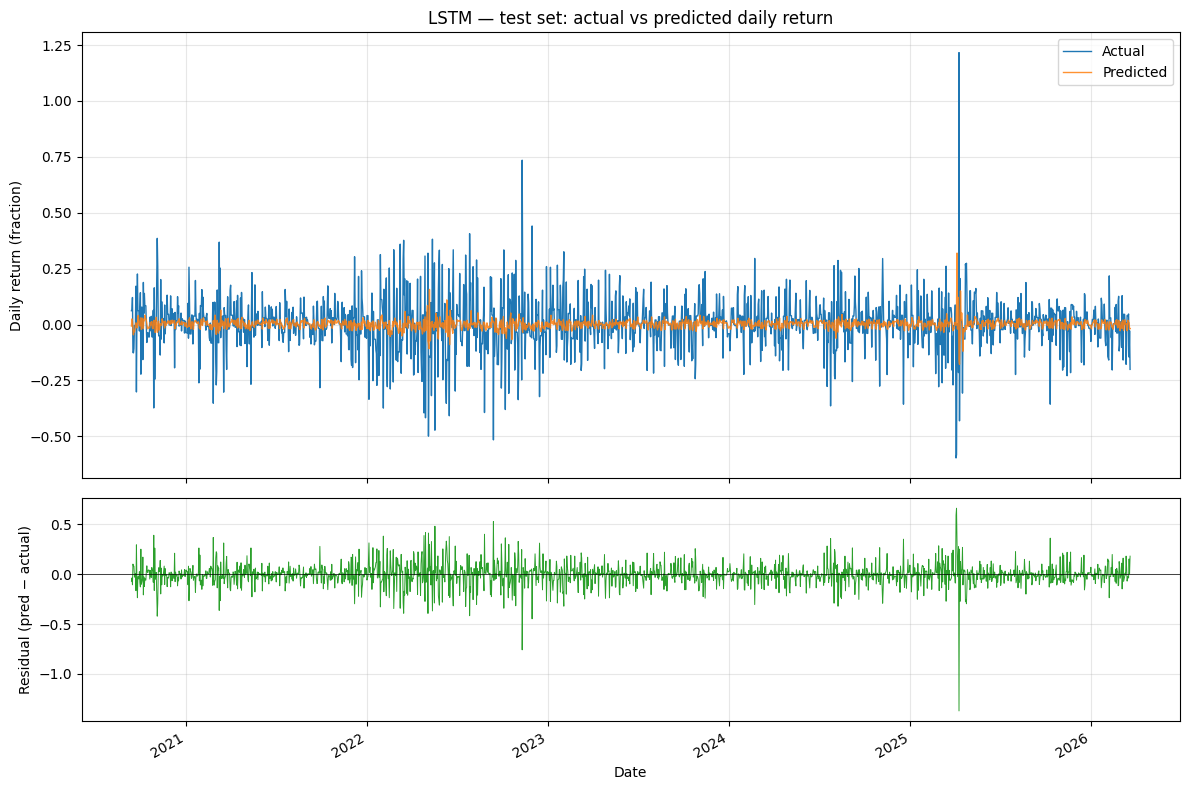

In [22]:
"""Plot LSTM test-set predictions vs actual daily returns (requires trained `models/Vanilla_LSTM.pth`)."""

from __future__ import annotations

import sys
from pathlib import Path

from matplotlib.pylab import f
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, TensorDataset


MODEL_SAVE_PATH = Path("models/Vanilla_LSTM.pth")
DATASET_PATH = Path("datasets_aligned/NASDAQCOM.csv")

def retrieve_price_from_percentage_change(changes: np.ndarray) -> np.ndarray:
    prices = np.zeros_like(changes)
    prices[0] = 100.0
    for i in range(1, len(changes)):
        prices[i] = prices[i - 1] * (1 + changes[i] / 10)
    return prices

def load_test_split(dataset_path: Path) -> tuple[torch.Tensor, torch.Tensor, np.ndarray]:
    df = pd.read_csv(dataset_path)
    original_data = torch.tensor(df["NASDAQCOM"].values, dtype=torch.float32)
    test_start = int(len(original_data) * VAL_RATIO - WINDOW_SIZE - 1)

    data = get_daily_percentage_change(original_data)
    test_x, test_y = build_windows(data[test_start:], WINDOW_SIZE)


    dates = pd.to_datetime(df["date"], format="%Y-%m-%d")
    # Align with build_windows: first y is data[test_start + WINDOW_SIZE]
    test_dates = np.array(dates[test_start + WINDOW_SIZE :])
    return test_x, test_y, test_dates

def load_model(model_save_path: Path) -> tuple[MyLSTMSequential, torch.device]:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = MyLSTMSequential(
        input_size=1,
        hidden_size=HIDDEN_SIZE,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
        output_size=1,
    ).to(device)
    try:
        state = torch.load(model_save_path, map_location=device, weights_only=True)
    except TypeError:
        state = torch.load(model_save_path, map_location=device)
    model.load_state_dict(state)
    model.eval()
    return model, device

def calculate_directional_accuracy(preds: np.ndarray, targets: np.ndarray) -> float:
    correct = 0
    for pred, target in zip(preds, targets):
        if (pred > 0 and target > 0) or (pred < 0 and target < 0):
            correct += 1
    return correct / len(preds)

def calculate_mean_absolute_error(preds: np.ndarray, targets: np.ndarray) -> float:
    return np.mean(np.abs(preds - targets))

def calculate_mean_squared_error(preds: np.ndarray, targets: np.ndarray) -> float:
    return np.mean(np.square(preds - targets))

def plot_predictions(preds: np.ndarray, targets: np.ndarray, test_dates: np.ndarray) -> None:
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
    axes[0].plot(test_dates, targets, label="Actual", linewidth=1.0)
    axes[0].plot(test_dates, preds, label="Predicted", linewidth=1.0, alpha=0.85)
    axes[0].set_ylabel("Daily return (fraction)")
    axes[0].set_title("LSTM — test set: actual vs predicted daily return")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    residual = preds - targets
    axes[1].plot(test_dates, residual, color="C2", linewidth=0.7)
    axes[1].axhline(0.0, color="black", linewidth=0.5)
    axes[1].set_ylabel("Residual (pred − actual)")
    axes[1].set_xlabel("Date")
    axes[1].grid(True, alpha=0.3)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

def calculate_f1_score_up(preds: np.ndarray, targets: np.ndarray) -> float:
    tp = fp = fn = 0
    for pred, target in zip(preds, targets):
        if pred > 0 and target > 0:
            tp += 1
        elif pred > 0 and target <= 0:
            fp += 1
        elif pred <= 0 and target > 0:
            fn += 1
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    return f1

def calculate_f1_score_down(preds: np.ndarray, targets: np.ndarray) -> float:
    tn = fp = fn = 0
    for pred, target in zip(preds, targets):
        if pred <= 0 and target <= 0:
            tn += 1
        elif pred > 0 and target <= 0:
            fp += 1
        elif pred <= 0 and target > 0:
            fn += 1
    precision = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    recall = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    return f1

def calculate_f1_score_macro(preds: np.ndarray, targets: np.ndarray) -> float:
    f1_up = calculate_f1_score_up(preds, targets)
    f1_down = calculate_f1_score_down(preds, targets)
    return (f1_up + f1_down) / 2

def main() -> None:
    if not MODEL_SAVE_PATH.is_file():
        raise FileNotFoundError(
            f"Missing model at {MODEL_SAVE_PATH}. Run LSTM_training.py from the project root first."
        )
    if not DATASET_PATH.is_file():
        raise FileNotFoundError(f"Missing dataset at {DATASET_PATH}")

    test_x, test_y, test_dates = load_test_split(DATASET_PATH)

    model, device = load_model(MODEL_SAVE_PATH)
    pin = device.type == "cuda"

    test_loader = DataLoader(
        TensorDataset(test_x, test_y),
        batch_size=BATCH_SIZE,
        shuffle=False,
        pin_memory=pin,
    )
    all_preds: list[torch.Tensor] = []
    all_targets: list[torch.Tensor] = []
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.to(device, non_blocking=pin)
            targets = targets.to(device, non_blocking=pin)
            outputs = model(inputs)
            all_preds.append(outputs.squeeze(-1).cpu())
            all_targets.append(targets.cpu())

    preds = np.concatenate(all_preds)
    targets = np.concatenate(all_targets)
    
    always_up_stretgy = np.array([0.1] * len(targets))
    da_up = calculate_directional_accuracy(always_up_stretgy, targets)
    mse_up = calculate_mean_squared_error(always_up_stretgy, targets)
    mae_up = calculate_mean_absolute_error(always_up_stretgy, targets)
    f1_up_up = calculate_f1_score_up(always_up_stretgy, targets)
    f1_up_down = calculate_f1_score_down(always_up_stretgy, targets)
    print(f"Always up directional accuracy: {da_up:.8f}")
    print(f"Always up MSE (daily fractional return): {mse_up:.8f}")
    print(f"Always up MAE (daily fractional return): {mae_up:.8f}")
    print(f"Always up F1 score (up): {f1_up_up:.8f}")
    print(f"Always up F1 score (down): {f1_up_down:.8f}")

    mse = calculate_mean_squared_error(preds, targets)
    mae = calculate_mean_absolute_error(preds, targets)
    da = calculate_directional_accuracy(preds, targets)
    f1_up = calculate_f1_score_up(preds, targets)
    f1_down = calculate_f1_score_down(preds, targets)
    print(f"Test MSE (daily fractional return): {mse:.8f}")
    print(f"Test MAE (daily fractional return): {mae:.8f}")
    print(f"Test directional accuracy: {da:.8f}")
    print(f"Test F1 score (up): {f1_up:.8f}")
    print(f"Test F1 score (down): {f1_down:.8f}")
    
    plot_predictions(preds, targets, test_dates)


if __name__ == "__main__":
    main()
